#Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

In [ ]:
# Load dataset from https://www.kaggle.com/datasets/ramisashararnidhi/mall-customer-csv
df = pd.read_csv("mall customers.csv")

# Data Exploration
print(df.head())
print(df.info())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


#Data Preparation

In [ ]:
# Select features used for clustering
data = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Drop missing values if any
data = data.dropna()

# Scale data for better clustering
scaler = StandardScaler()

scaled_data = scaler.fit_transform(data)

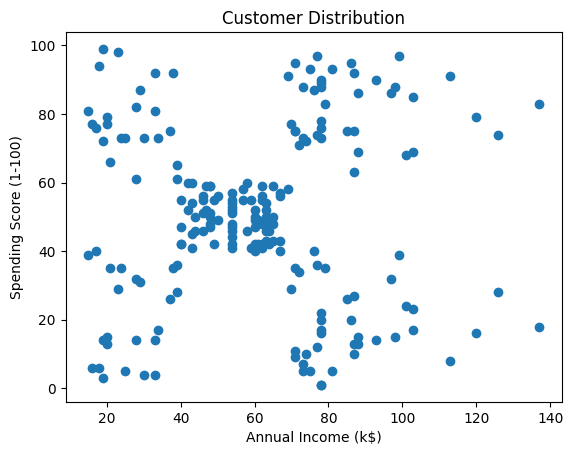

In [ ]:
# Visualization of relationship between income and spending
plt.scatter(data['Annual Income (k$)'],data['Spending Score (1-100)'])
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Distribution")
plt.show()


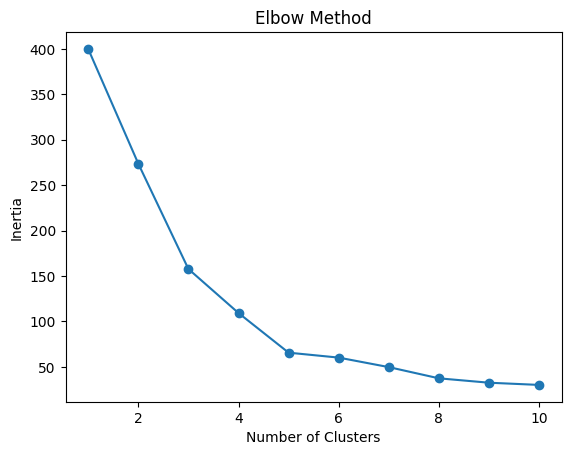

In [ ]:
# Elbow method to find the optimal number of clusters

# Inertia value storage
inertia = []

# Test cluster counts from 1 to 10
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

# Plot curve
plt.plot(range(1,11), inertia, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()


In [ ]:
# Train KMM using the optimal number of clusters found using the elbow method
kmeans = KMeans(n_clusters=5, random_state=42)

clusters = kmeans.fit_predict(scaled_data)

# Add cluster labels to dataset
data['Cluster'] = clusters

# Models

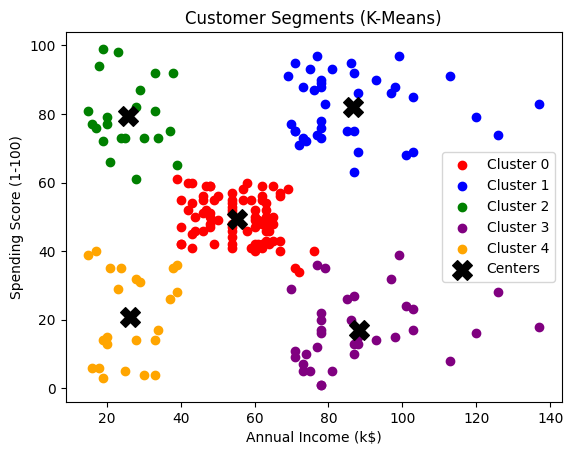

In [ ]:
# Visualization of clusters
colors = ['red','blue','green','purple','orange']

plt.figure()

for i in range(5):

    cluster_points = data[data['Cluster'] == i]

    plt.scatter(cluster_points['Annual Income (k$)'],cluster_points['Spending Score (1-100)'],color=colors[i],label=f'Cluster {i}')

# Convert centers to original scale
centers = scaler.inverse_transform(kmeans.cluster_centers_)

# Plot centers
plt.scatter(centers[:,0],centers[:,1],marker='X',s=200,color='black',label='Centers')

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments (K-Means)")
plt.legend()

plt.show()


# Bonus

In [ ]:
# Average Spending per Cluster
cluster_summary = data.groupby('Cluster').mean()

print("Summary of Clusters:")
print(cluster_summary)

Summary of Clusters:
         Annual Income (k$)  Spending Score (1-100)  DBSCAN_Cluster
Cluster                                                            
0                 55.296296               49.518519        0.000000
1                 86.538462               82.128205        0.794872
2                 25.727273               79.363636        0.000000
3                 88.200000               17.114286       -0.114286
4                 26.304348               20.913043        0.000000


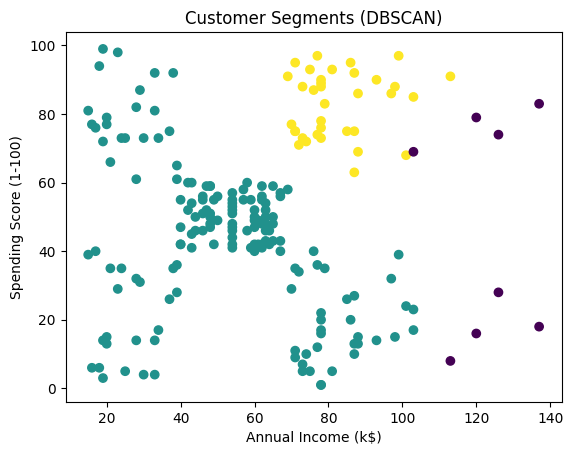

In [ ]:
# DBSCAN of Clusters
dbscan = DBSCAN(eps=0.5, min_samples=5)

db_clusters = dbscan.fit_predict(scaled_data)

# Add DBSCAN clusters
data['DBSCAN_Cluster'] = db_clusters

# Visualization of DBSCAN Clusters
plt.scatter(data['Annual Income (k$)'],data['Spending Score (1-100)'],c=data['DBSCAN_Cluster'])
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments (DBSCAN)")

plt.show()
